## Phase 1 Mass Analysis

In [18]:
    library(lme4) #for linear mixed effects model
    library(readr) #to read in data
    library(emmeans) #for post hocs
    library(esquisse) #interface for building plots
    library(dplyr) #for data wrangling
    library(nlme) #for linear mixed effects model
    library(car) #for the Levene test
    library(ggplot2) #for graphs
    library(plotrix) #for standard error
    library(performance) #model testing
    library(lmtest) #another option than levene test for variance

In [19]:
getwd()

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Weight_Data"

In [33]:
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

### read in data

In [38]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### filter to not include data from dead oysters/ doubles in analysis
  ### excludes doubles but keeps oysters that died in the second phase, as all oysters were alive for first measurements

In [39]:
Growth_Data_forR_pre <- Growth_Data_forR %>%
  filter(Exclude_pre_analysis != "Y" | is.na(Exclude_pre_analysis)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
         prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg,
         meat_yield = (Actual_tissue_pre_mg/(Dry_weight_pre)))

In [43]:
options(contrasts = c("contr.sum","contr.sum")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum" "contr.sum"

#### Effect of phase 1 at the start of phase 2

# diagnostics

In [ ]:
leveneTest(log(Actual_tissue_pre_mg)~Phase_1_treat, Growth_Data_forR_pre)
m1.e <- residuals(Tm1) 
qqnorm(m1.e)
qqline(m1.e)

In [44]:
Tm1 <- lmer(log(Actual_tissue_pre_mg)~ Phase_1_DO*Phase_1_temp +
              (1|Phase_1_rep_R), data = Growth_Data_forR_pre, REML=TRUE)
Anova(Tm1, test="F", type="III")

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),6.497614e+04,1,19.99963,1.342945e-36
Phase_1_DO,8.026895e+00,1,19.99963,1.027378e-02
Phase_1_temp,1.211603e-01,1,19.99963,7.314165e-01
Phase_1_DO:Phase_1_temp,4.045440e-02,1,19.99963,8.426262e-01


In [45]:
emmeans(Tm1,specs = pairwise ~ Phase_1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE df lower.CL upper.CL
 Hyp          5.25 0.0295 20     5.19     5.32
 Norm         5.37 0.0295 20     5.31     5.43

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE df t.ratio p.value
 Hyp - Norm   -0.118 0.0417 20  -2.833  0.0103

Results are averaged over the levels of: Phase_1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


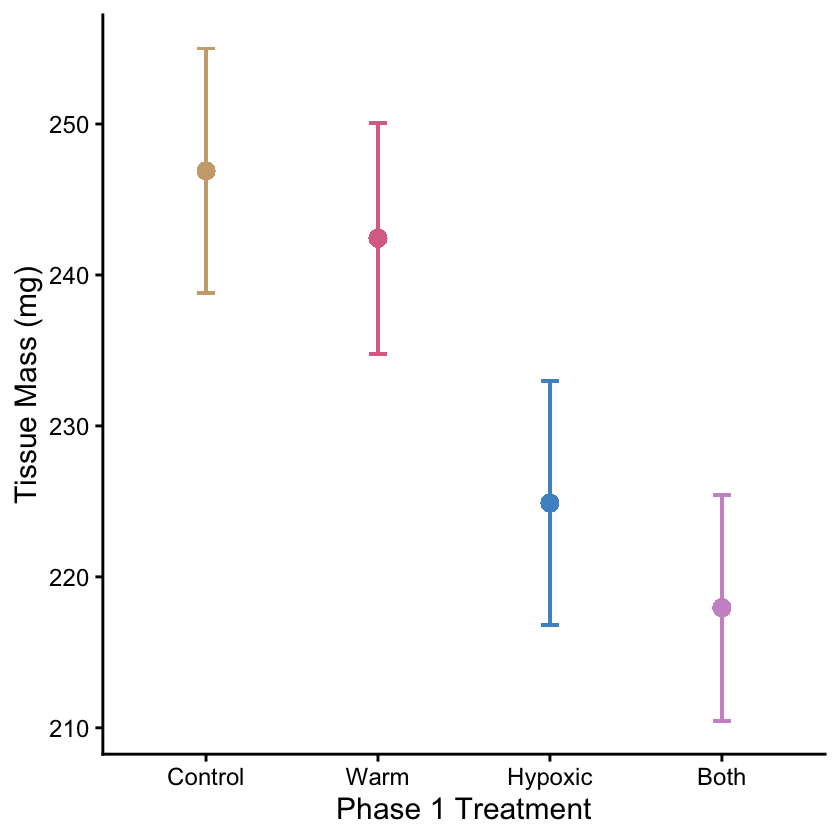

In [48]:
#effect of phase 1, TISSUE
pre_summary_stats_t <- Growth_Data_forR_pre %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_pre = mean(Actual_tissue_pre_mg, na.rm = TRUE),
    se_pre = std.error(Actual_tissue_pre_mg, na.rm = TRUE))

  #reorder effect of phase 1 Phase_1_treat
  pre_summary_stats_t$Phase_1_treat <- factor(pre_summary_stats_t$Phase_1_treat, 
                                            levels = c("Cont", "Warm","Hyp", "Both"))
  #plot TISSUE
  ggplot(pre_summary_stats_t, aes(x = Phase_1_treat, y = mean_pre, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_pre - se_pre, ymax = mean_pre + se_pre), 
                  width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18)+
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Tissue Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend
